# Boosted Decision Tree Skeleton


In [1]:
import awkward as ak
import uproot
import polars as pl

from fastfeedback import DataManager, Method

method = 0b00
direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
energy_reco = Method.Truth if method & 1 << 1 else Method.Reco

print(f"""
Direction reconstruction: {direc_reco.name}
Energy reconstruction:    {energy_reco.name}
""")

data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")
data_manager.set_data_selection(pl.lit(True))
data_manager.set_direc_reco(direc_reco)
data_manager.set_energy_reco(energy_reco)

df = data_manager.prepare_data()
df = df["recoE", "direc_reco"]

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]
Enu_e_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
nuPDG = "rec/mc/mc.nu/mc.nu.pdg"
true_inelasticity = "rec/mc/mc.nu/mc.nu.inelasticity"

df2 = pl.from_pandas(
    ak.to_dataframe(
        caf_tree.arrays(
            [Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, nuPDG, true_inelasticity]
        ),
        how="outer",
    ),
)
df2.columns = [
    "Enu_e_had",
    "Enu_e_calo",
    "Enu_mu_had",
    "Enu_mu_range",
    "nuPDG",
    "true_inelasticity",
]

event_daughters_tree = uproot.open("example-cafs-root/event_daughters_info.root")[
    "event_daughters_tree"
]
event_daughters_df: pl.DataFrame = pl.from_pandas(
    event_daughters_tree.arrays(library="pd")
)

electron_mask = pl.col("nuPDG").abs() == 12
muon_mask = pl.col("nuPDG").abs() == 14

electron_inelasticity = 1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))
muon_inelasticity = 1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))

data: pl.DataFrame = (
    pl.concat([df, df2, event_daughters_df], how="horizontal")
    .filter(pl.col("reco_ok") == True)
    .filter(pl.col("direc_reco") != 0)
    .with_columns(
        pl.when(electron_mask)
        .then(electron_inelasticity)
        .when(muon_mask)
        .then(muon_inelasticity)
        .otherwise(None)
        .alias("reco_inelasticity")
    )
    .drop_nulls()
)

data


Direction reconstruction: Reco
Energy reconstruction:    Reco

Loading data...


/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


recoE,direc_reco,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,nuPDG,true_inelasticity,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,n_true_nu,n_primary_daughters,n_primary_electrons,n_primary_muons,n_primary_protons,n_primary_pions,n_primary_photons,n_primary_pi0s,n_primary_tracks,n_primary_showers,reco_inelasticity
f64,f64,f32,f32,f32,f32,i32,f32,bool,i32,i32,i32,f32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f32
28.432413,-0.291152,12.376396,28.432413,28.015844,28.529816,-12,0.097032,true,10,5,4,11.48799,4,1,1,5,1,0,0,1,0,1,1,3,0.564708
0.208079,0.092648,0.09995,0.208079,0.09995,0.322256,-12,0.543771,true,2,1,0,0.11094,1,0,1,4,1,0,1,0,1,0,1,1,0.519653
1.20171,0.167917,0.306345,1.156426,0.306345,1.20171,-14,0.46456,true,4,3,0,0.06457,2,1,1,6,0,1,0,2,0,0,3,0,0.745076
0.5937,0.577708,0.088844,0.502835,0.088844,0.5937,14,0.208293,true,3,2,0,0.00242,1,1,1,3,0,1,1,0,1,0,2,0,0.850355
0.021875,-0.950973,0.0,0.021875,0.0,0.1223,-12,0.36196,true,2,1,0,0.010483,0,1,1,3,0,0,1,0,0,0,1,0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.704717,0.113819,0.444597,0.893467,0.444597,0.903641,14,0.052372,true,4,2,1,0.164924,1,1,1,2,0,1,1,0,0,0,2,0,0.507993
2.243878,0.899609,-8.1044e-17,0.156685,0.0,0.256748,14,0.597658,true,2,1,0,0.0,1,0,1,3,0,0,1,0,1,0,1,0,1.0
0.260973,-0.396677,0.002552,0.169946,0.002552,0.260973,14,0.17144,true,2,1,0,0.005397,1,0,1,3,0,1,1,0,0,0,2,0,0.990219


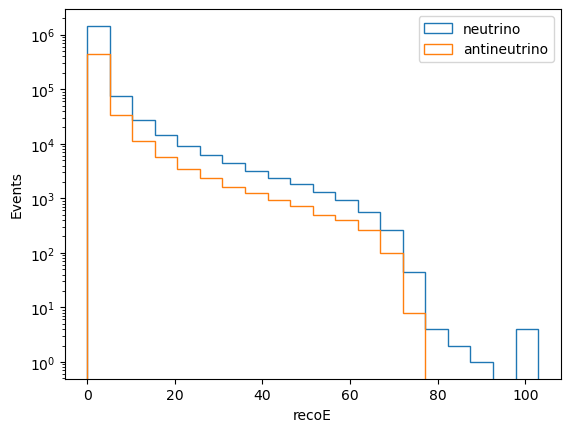

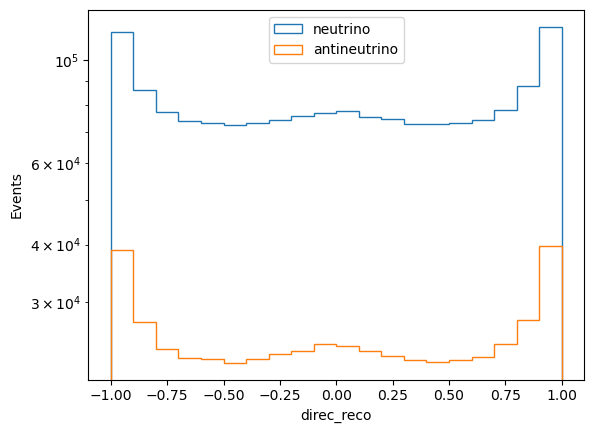

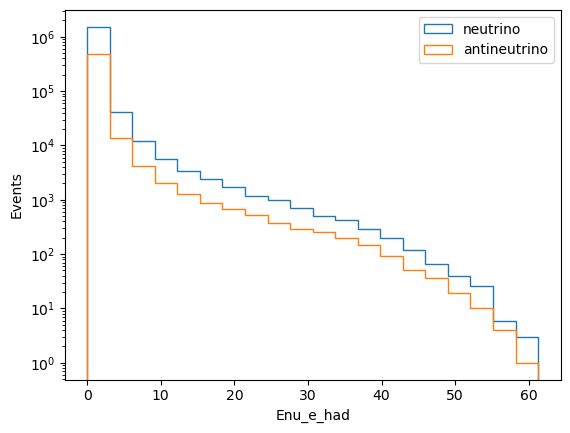

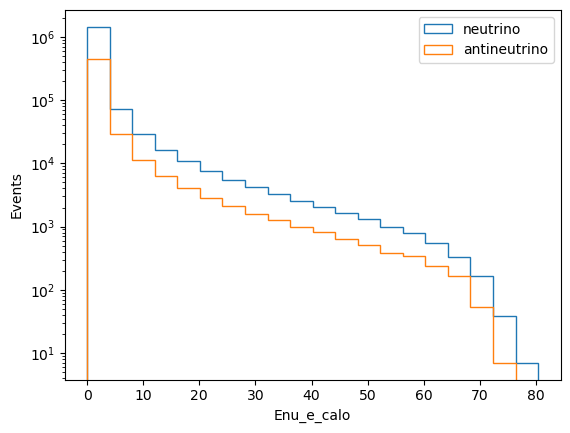

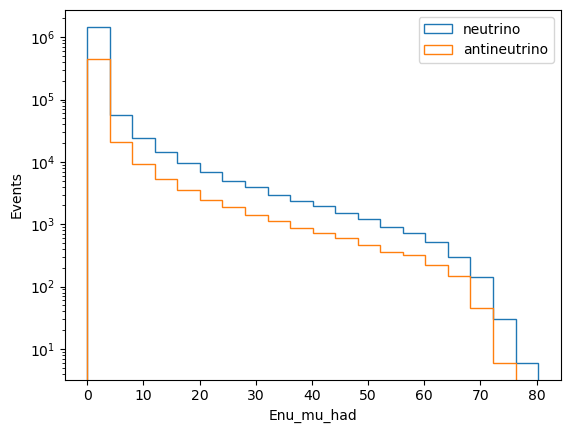

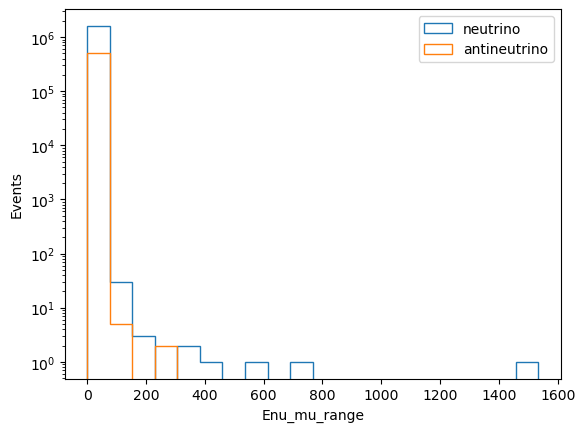

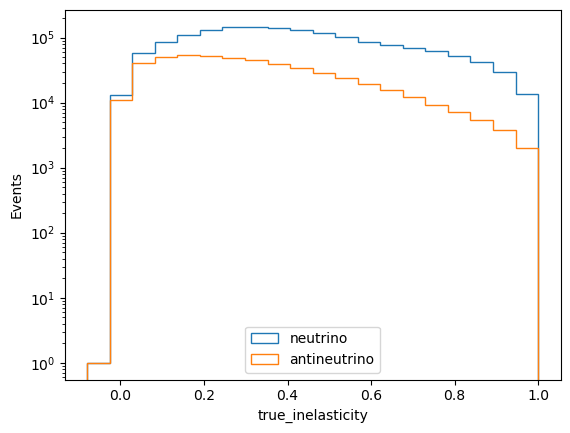

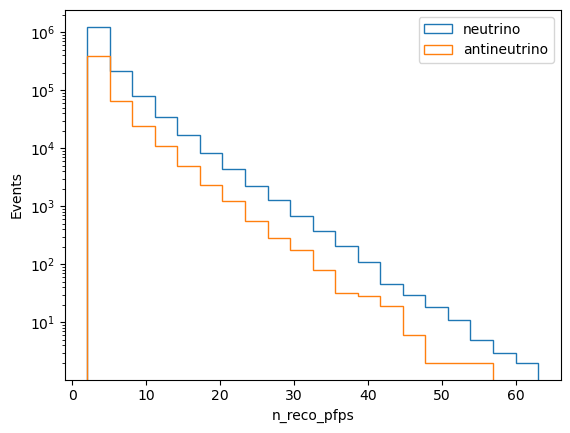

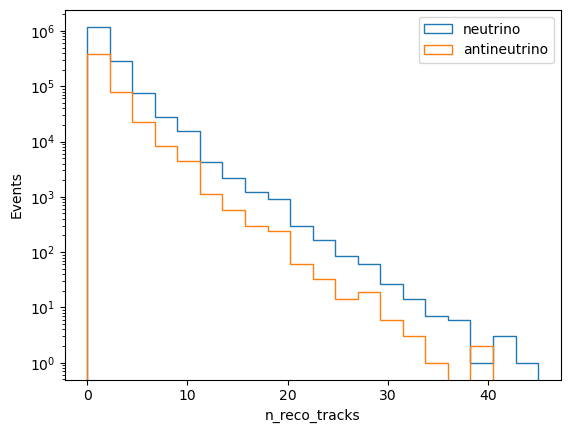

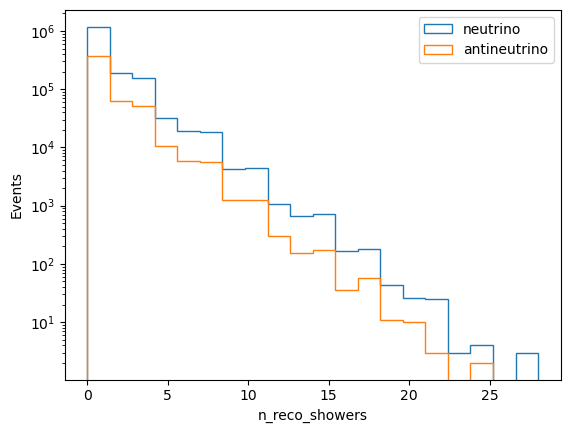

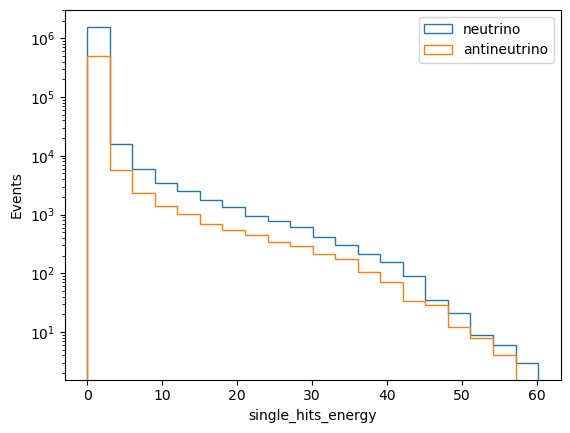

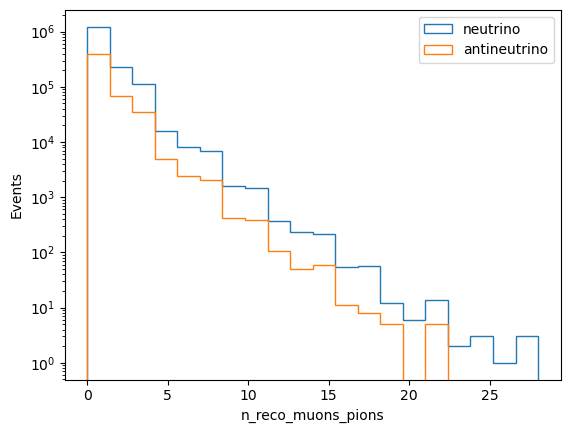

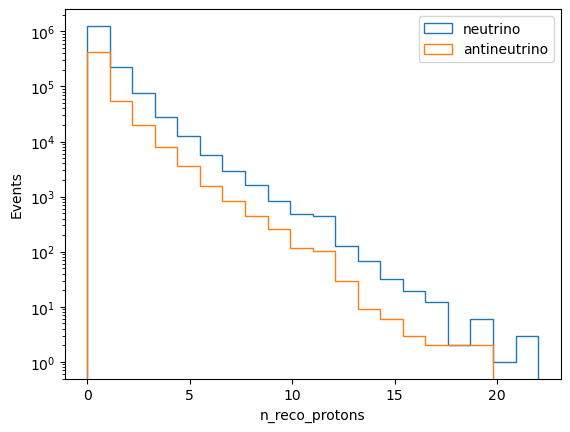

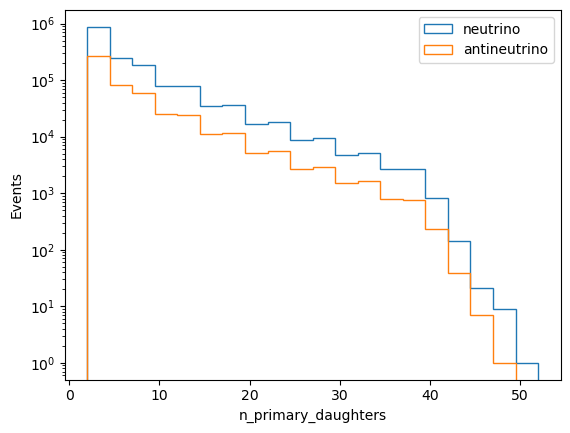

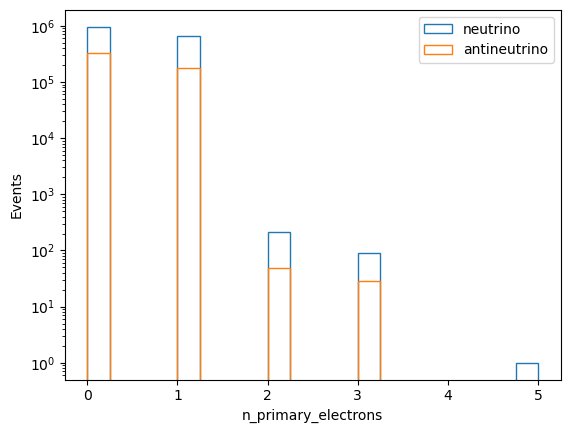

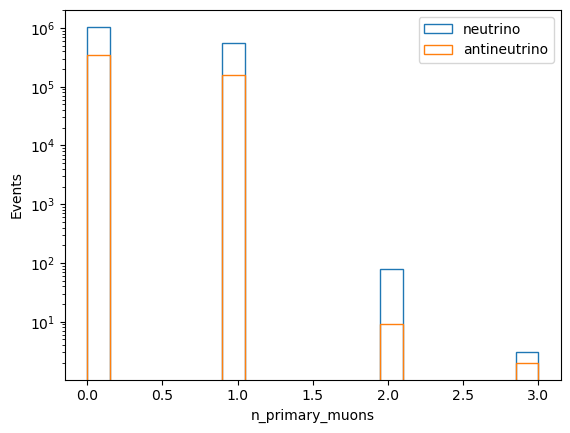

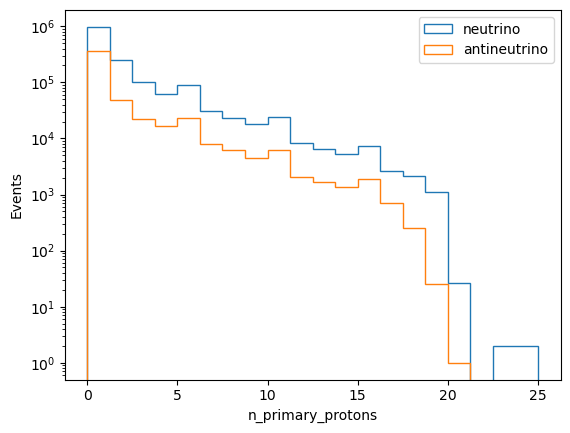

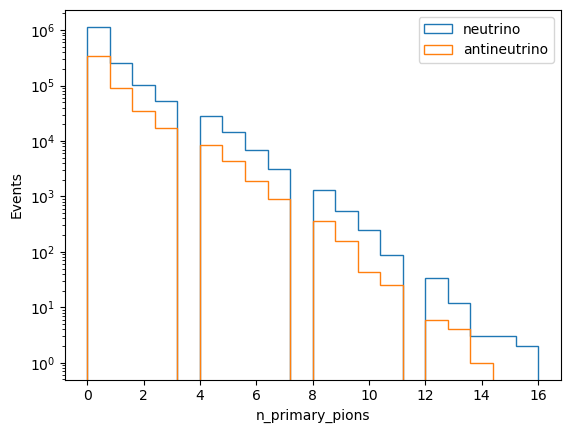

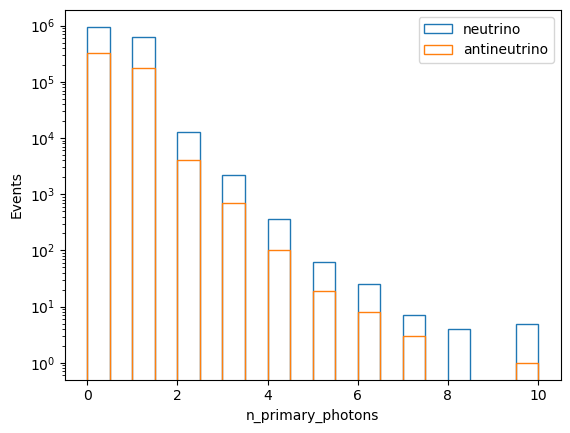

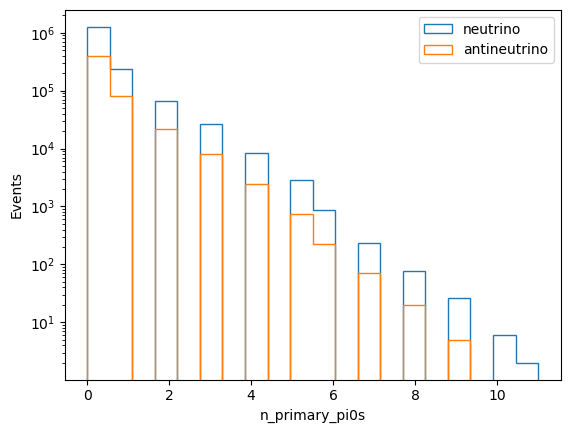

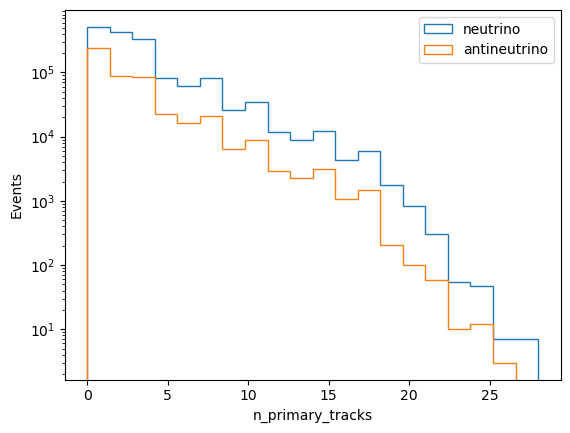

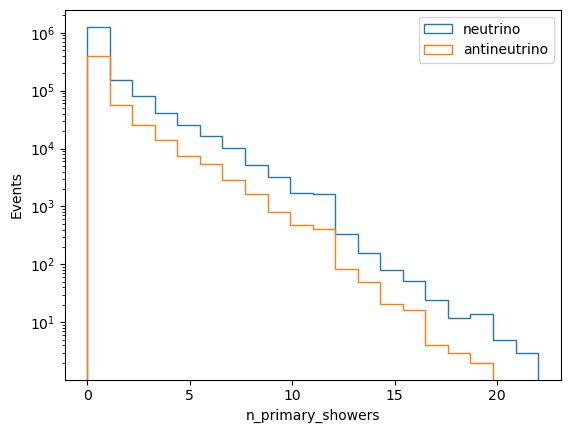

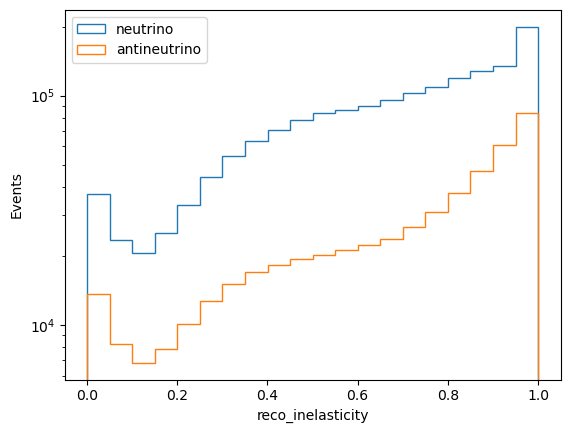

In [ ]:
import matplotlib.pyplot as plt

nu_mask = pl.col("nuPDG") > 0
nubar_mask = pl.col("nuPDG") < 0

for col in data.columns:
    if col in ["nuPDG", "reco_ok", "n_true_nu"]:
        continue

    _, bins, _ = plt.hist(
        data.filter(nu_mask)[col],
        label="neutrino",
        histtype="step",
        bins=20,
    )
    plt.hist(
        data.filter(nubar_mask)[col],
        label="antineutrino",
        histtype="step",
        bins=bins,
    )
    plt.legend()
    plt.yscale("log")
    plt.xlabel(col)
    plt.ylabel("Events")
    plt.show()

In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

# get your input data into an array which is N_events x N_variables
X_data = data.drop("nuPDG")

# create an array of truth labels (one per event) - 0 for neutrino, 1 for anti-neutrino
y_data = (data["nuPDG"] < 0).to_numpy().astype(int)
y_data_uniques = np.unique(y_data)
print(y_data_uniques)

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, random_state=0)
X_data

[0 1]


recoE,direc_reco,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,true_inelasticity,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,n_true_nu,n_primary_daughters,n_primary_electrons,n_primary_muons,n_primary_protons,n_primary_pions,n_primary_photons,n_primary_pi0s,n_primary_tracks,n_primary_showers,reco_inelasticity
f64,f64,f32,f32,f32,f32,f32,bool,i32,i32,i32,f32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f32
28.432413,-0.291152,12.376396,28.432413,28.015844,28.529816,0.097032,true,10,5,4,11.48799,4,1,1,5,1,0,0,1,0,1,1,3,0.564708
0.208079,0.092648,0.09995,0.208079,0.09995,0.322256,0.543771,true,2,1,0,0.11094,1,0,1,4,1,0,1,0,1,0,1,1,0.519653
1.20171,0.167917,0.306345,1.156426,0.306345,1.20171,0.46456,true,4,3,0,0.06457,2,1,1,6,0,1,0,2,0,0,3,0,0.745076
0.5937,0.577708,0.088844,0.502835,0.088844,0.5937,0.208293,true,3,2,0,0.00242,1,1,1,3,0,1,1,0,1,0,2,0,0.850355
0.021875,-0.950973,0.0,0.021875,0.0,0.1223,0.36196,true,2,1,0,0.010483,0,1,1,3,0,0,1,0,0,0,1,0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.704717,0.113819,0.444597,0.893467,0.444597,0.903641,0.052372,true,4,2,1,0.164924,1,1,1,2,0,1,1,0,0,0,2,0,0.507993
2.243878,0.899609,-8.1044e-17,0.156685,0.0,0.256748,0.597658,true,2,1,0,0.0,1,0,1,3,0,0,1,0,1,0,1,0,1.0
0.260973,-0.396677,0.002552,0.169946,0.002552,0.260973,0.17144,true,2,1,0,0.005397,1,0,1,3,0,1,1,0,0,0,2,0,0.990219


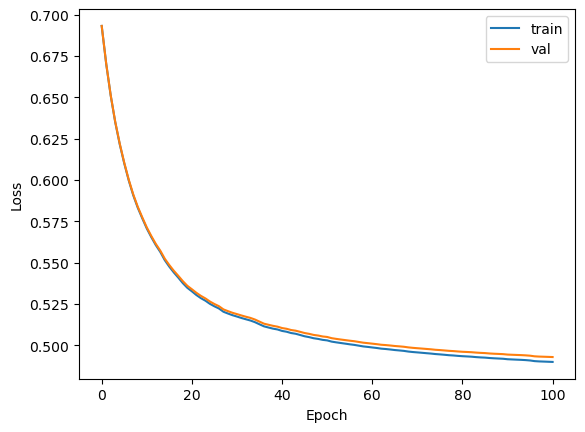

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt

clf = HistGradientBoostingClassifier(random_state=0, class_weight="balanced").fit(
    X_train, y_train
)

scores_train = clf.decision_function(X_train)
scores_test = clf.decision_function(X_test)

train_loss = -clf.train_score_
val_loss = -clf.validation_score_

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

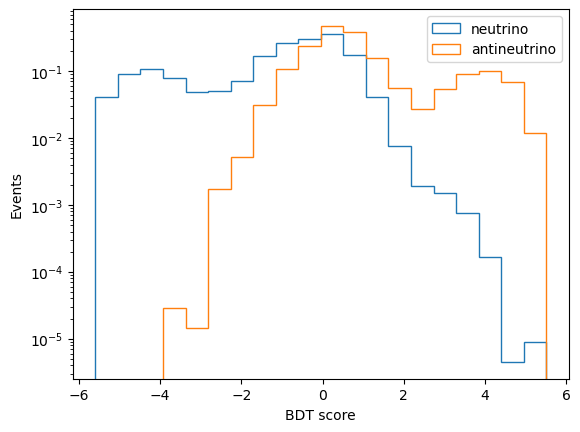

1.8018037611812745


In [5]:
nu_index = 0
nubar_index = 1

n, bins, _ = plt.hist(
    scores_test[y_test == nu_index],
    label="neutrino",
    histtype="step",
    bins=20,
    range=(scores_test.min(), scores_test.max()),
    density=True,
)
plt.hist(
    scores_test[y_test == nubar_index],
    label="antineutrino",
    histtype="step",
    bins=bins,
    density=True,
)
plt.legend()
plt.yscale("log")
plt.xlabel("BDT score")
plt.ylabel("Events")
plt.show()

print(np.sum(n))

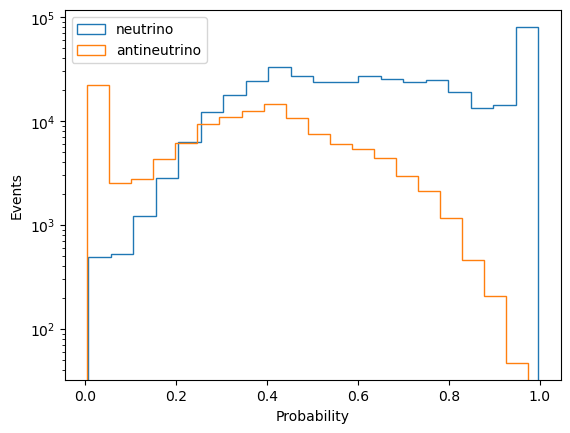

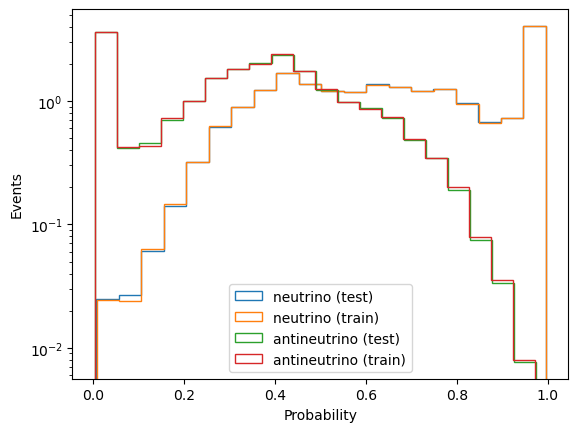

In [6]:
prob_test_nu = 1 / (1 + np.exp(scores_test[y_test == nu_index]))
prob_test_nubar = 1 / (1 + np.exp(scores_test[y_test == nubar_index]))
prob_train_nu = 1 / (1 + np.exp(scores_train[y_train == nu_index]))
prob_train_nubar = 1 / (1 + np.exp(scores_train[y_train == nubar_index]))

_, bins, _ = plt.hist(prob_test_nu, label="neutrino", histtype="step", bins=20)
plt.hist(prob_test_nubar, label="antineutrino", histtype="step", bins=20)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

_, bins, _ = plt.hist(
    prob_test_nu, label="neutrino (test)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_train_nu, label="neutrino (train)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_test_nubar, label="antineutrino (test)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_train_nubar,
    label="antineutrino (train)",
    histtype="step",
    bins=20,
    density=True,
)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

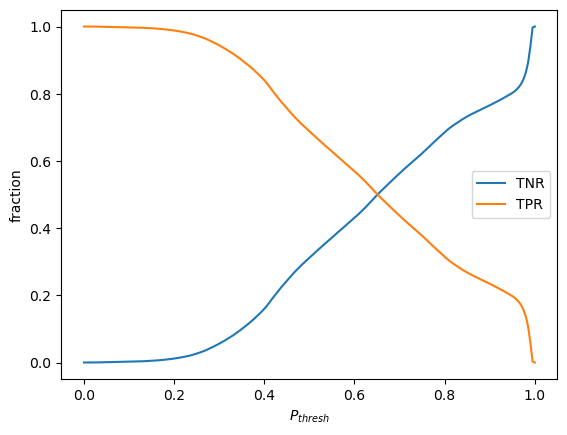

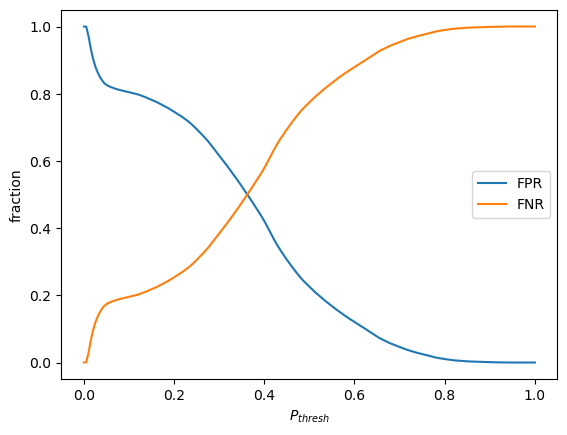

In [7]:
score_thresh = np.linspace(0, 1, 200)

tpr = [(prob_test_nu > score).sum() / len(prob_test_nu) for score in score_thresh]
fpr = [(prob_test_nubar > score).sum() / len(prob_test_nubar) for score in score_thresh]
tnr = [(prob_test_nu < score).sum() / len(prob_test_nu) for score in score_thresh]
fnr = [(prob_test_nubar < score).sum() / len(prob_test_nubar) for score in score_thresh]

plt.plot(score_thresh, tnr, label="TNR")
plt.plot(score_thresh, tpr, label="TPR")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("$P_{thresh}$")
plt.show()

plt.plot(score_thresh, fpr, label="FPR")
plt.plot(score_thresh, fnr, label="FNR")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("$P_{thresh}$")
plt.show()

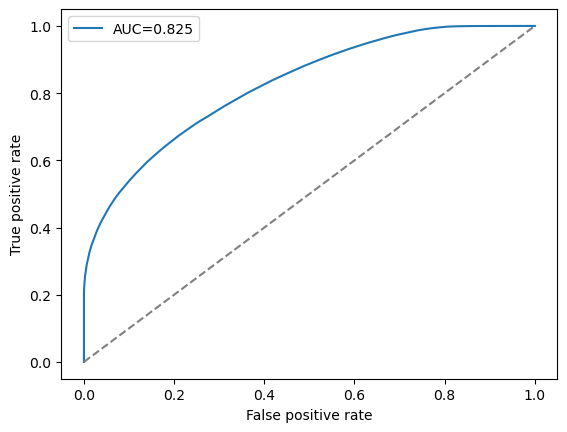

In [8]:
from scipy.integrate import trapezoid

auc = trapezoid(x=fpr[::-1], y=tpr[::-1])

# ROC
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

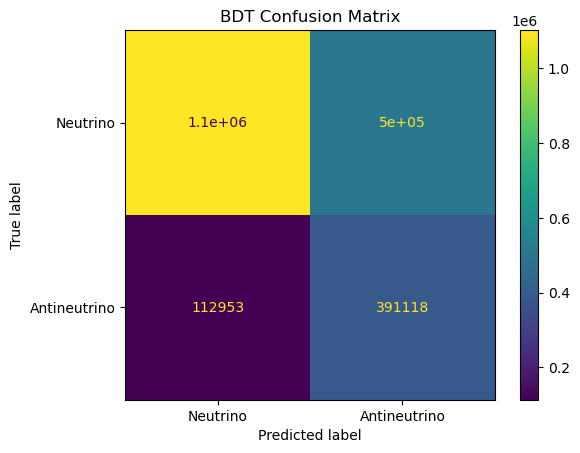

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_data.to_pandas())
cm = confusion_matrix(y_data, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Neutrino", "Antineutrino"])
disp.plot()
plt.title("BDT Confusion Matrix")
plt.show()

In [10]:
from sklearn.inspection import permutation_importance

r = permutation_importance(clf, X_data.to_pandas(), y_data, random_state=0)
for name, val in sorted(zip(X_data.columns, r["importances_mean"]), key=lambda x: x[1]):
    print(name, val)

recoE -0.005089490234927307
single_hits_energy -0.0030997534772236658
Enu_mu_range -0.0025381028563620455
Enu_e_calo -0.0013621379730475835
n_reco_protons -0.00102736801352743
n_primary_showers -0.000989791793581274
n_primary_pi0s -0.0005514025608763351
Enu_mu_had -0.0003387553161811496
n_reco_muons_pions -8.758295709667684e-05
direc_reco 0.0
reco_ok 0.0
n_true_nu 0.0
reco_inelasticity 0.0009801130702618232
n_reco_tracks 0.0018392420990304358
n_reco_showers 0.002093640699221355
Enu_e_had 0.003280612758075563
n_reco_pfps 0.003934306139916388
n_primary_pions 0.007480894010388495
n_primary_electrons 0.019028939382725187
n_primary_muons 0.019396825758308988
n_primary_tracks 0.025027375604683
n_primary_photons 0.03127669951739227
true_inelasticity 0.0682362329649725
n_primary_daughters 0.08117497803309366
n_primary_protons 0.12279680943732456


In [28]:
max_prod_score = 0
max_prod = 0

for score in score_thresh:
    true_positive = np.count_nonzero(prob_test_nu > score)
    false_positive = np.count_nonzero(prob_test_nubar > score)
    true_negative = np.count_nonzero(prob_test_nu < score)
    false_negative = np.count_nonzero(prob_test_nubar < score)

    if true_positive + false_negative == 0 or true_positive + false_positive == 0:
        continue

    efficiency = true_positive / (true_positive + false_negative)
    purity = true_positive / (true_positive + false_positive)

    if efficiency * purity > max_prod:
        max_prod = efficiency * purity
        max_prod_score = score

print(max_prod_score)

0.0
